In [1]:
def rqthree():
    baseline_en_path = "../../../../results/evaluation/gpt-5-nano/results_EN_e20-subset.parquet"
    baseline_nl_path = "../../../../results/evaluation/gpt-5-nano/results_NL_e20-subset.parquet"
    NPO_en_path = "../../../../results/evaluation/gpt-5-nano/results_EN_NPO_e20-ue3-subset.parquet"
    NPO_nl_path = "../../../../results/evaluation/gpt-5-nano/results_NL_NPO_e20-ue3-subset.parquet"

    output_dir = "publication/rq3"
    mmu_output = f"{output_dir}/mmu"
    advanced_output = f"{output_dir}/advanced"

    model_results = {
            "Finetuned (English)": baseline_en_path,
            "Finetuned (Dutch)": baseline_nl_path,
            "NPO (English)": NPO_en_path,
            "NPO (Dutch)": NPO_nl_path
        }

    factor_map = {
        "Finetuned (English)": ("English", "Finetuned"),
        "Finetuned (Dutch)": ("Dutch", "Finetuned"),
        "NPO (English)": ("English", "NPO"),
        "NPO (Dutch)": ("Dutch", "NPO")
    }

    return mmu_output, advanced_output, model_results, factor_map

In [2]:
def rqtwo():
    finetuned_en_path = "../../../../results/evaluation/gpt-5-nano/results_EN_e20-subset.parquet"
    finetuned_nl_path = "../../../../results/evaluation/gpt-5-nano/results_NL_e20-subset.parquet"
    baseline_en_path = "../../../../results/evaluation/gpt-5-nano/results_EN_baseline.parquet"
    baseline_nl_path = "../../../../results/evaluation/gpt-5-nano/results_NL_baseline.parquet"

    output_dir = "publication/rq2"
    mmu_output = f"{output_dir}/mmu"
    advanced_output = f"{output_dir}/advanced"

    model_results = {
            "Baseline (English)": baseline_en_path,
            "Baseline (Dutch)": baseline_nl_path,
            "Finetuned (English)": finetuned_en_path,
            "Finetuned (Dutch)": finetuned_nl_path,
        }

    factor_map = {
        "Baseline (English)": ("English", "Baseline"),
        "Baseline (Dutch)": ("Dutch", "Baseline"),
        "Finetuned (English)": ("English", "Finetuned"),
        "Finetuned (Dutch)": ("Dutch", "Finetuned"),
    }

    return mmu_output, advanced_output, model_results, factor_map

In [3]:
mmu_output, advanced_output, model_results, factor_map = rqthree()
significance_level=0.05

In [4]:
from psalm.evaluators.multi_analyzer import MultiModelUnlearningAnalyzer

analyzer = MultiModelUnlearningAnalyzer(
    files=model_results,
    alpha=significance_level,               # significance level
    correction="holm",        # Holm–Bonferroni multiple‑test correction
    prefer_nonparametric=True, # use nonparametric tests (Mann–Whitney, Kruskal)
    verbose=True
)

Loaded 4 models, 2080 rows, 13 metrics.


In [5]:
analyzer.run_full_comparison(
    out_dir=mmu_output,   # directory for all plots + tables
    analyze_split="both"     # options: "both", "forget", or "retain"
)


STARTING MULTI-MODEL UNLEARNING COMPARISON

1) Computing per-metric statistics...
   ✓ Done.
2) Computing per-category aggregates...
   ✓ Done.
3) Computing overall ranks...
   ✓ Done.
4) Generating plots...
✓ Saved publication\rq3\mmu\metric_violins_split.png
✓ Saved publication\rq3\mmu\metric_boxplots_split.png
✓ Saved publication\rq3\mmu\mean_heatmap_split.png
✓ Saved publication\rq3\mmu\avg_rank_split.png
   ✓ Plots saved.
5) Exporting tables...
✓ Saved tables (CSV/Excel)
   ✓ Tables saved.
6) Summary:
MULTI-MODEL UNLEARNING COMPARISON SUMMARY

OVERALL MODEL RANKING (lower AvgRank is better):
  Split: Forget
    Finetuned (English): AvgRank=1.85, MetricWins=13
    Finetuned (Dutch): AvgRank=2.00, MetricWins=13
    NPO (English): AvgRank=3.04, MetricWins=13
    NPO (Dutch): AvgRank=3.12, MetricWins=13
  Split: Retain
    Finetuned (English): AvgRank=1.77, MetricWins=13
    Finetuned (Dutch): AvgRank=1.92, MetricWins=13
    NPO (English): AvgRank=3.04, MetricWins=13
    NPO (Dutch):

In [6]:
from psalm.evaluators.advanced_statistical_tests import AdvancedStatisticalTests

advanced = AdvancedStatisticalTests(
    comparator=analyzer,
    factor_map=factor_map,
    alpha=significance_level,
    equivalence_bounds=(-0.1, 0.1),  # ±0.1 for stylometry preservation
    verbose=True
)


Detected conditions per language:
  English: Baseline='Finetuned', Treated='NPO'
  Dutch: Baseline='Finetuned', Treated='NPO'



ADVANCED STATISTICAL ANALYSIS


ANALYZING: FORGET SET

1) Checking parametric assumptions...
2) Running two-way ANOVA (Language × Condition)...
3) Running paired tests (baseline vs treated per language)...
5) Computing differential effects (all categories)...
6) Computing enhanced effect sizes...
7) Generating plots...
✓ Saved publication\rq3\advanced\interaction_forget_Computational_Exact_Match.png
✓ Saved publication\rq3\advanced\interaction_forget_Computational_BLEU.png
✓ Saved publication\rq3\advanced\interaction_forget_Computational_ROUGE.png
✓ Saved publication\rq3\advanced\interaction_forget_Stylistic_Writing_Style.png
✓ Saved publication\rq3\advanced\interaction_forget_Stylistic_Narrative_Voice.png
✓ Saved publication\rq3\advanced\interaction_forget_Content_Character_Similarity.png
✓ Saved publication\rq3\advanced\interaction_forget_Content_Plot_Structure_Similarity.png
✓ Saved publication\rq3\advanced\interaction_forget_Content_Scene_Sequence_Similarity.png
✓ Saved publicatio

KeyError: 'significant'

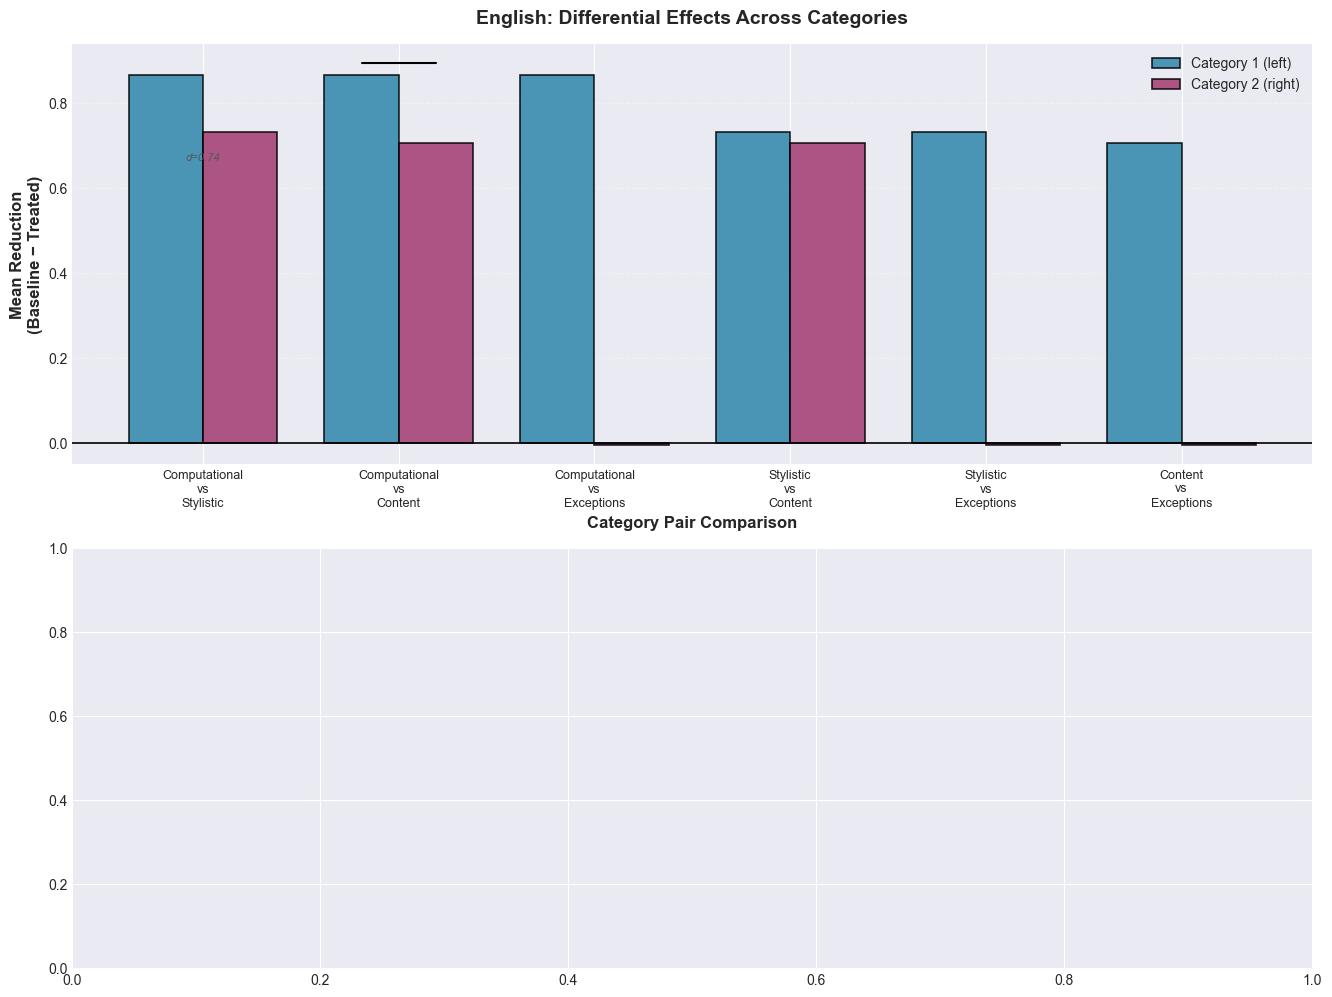

In [7]:
advanced.run_full_analysis(
    out_dir=advanced_output,
    test_splits=["forget", "retain"],
    parametric=False  # Use non-parametric
)